# Section 1: Email security

Compare TF-IDF + Logistic Regression with an LSTM using the SpamAssassin corpus. The labels are **ham and spam**, not legitimate and phishing emails, so the results should be described as spam detection.

This notebook contains the whole experiment. Existing outputs are from an earlier run, not a new run of this style revision. When rerunning, restart the kernel and work from top to bottom.

## Setup

The first cell assumes Colab's `/content` directory. Skip it when using a local kernel. The package versions below are not pinned.

In [1]:
import os
# Colab keeps files under /content; skip this cell when running locally.
os.chdir("/content")

In [2]:
%pip install -q joblib matplotlib numpy pandas scikit-learn torch

In [3]:
import hashlib
import json
import os
import random
import re
import shutil
import sys
import tarfile
import urllib.request
from collections import Counter
from email import policy
from email.parser import BytesParser
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, average_precision_score,
    classification_report, confusion_matrix, f1_score,
    precision_recall_curve, precision_score, recall_score,
    roc_auc_score, roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from torch import nn
from torch.utils.data import DataLoader, Dataset

### Experiment settings

Keep the seed, split sizes and epoch count together. Fixed seeds help repeatability, but different devices or package versions can still produce different results. Colab writes to its own workspace, not directly to the local repository.

In [4]:
seed = 42
test_size = 0.15
val_size = 0.15
epochs = 6

# Keep the data, saved models and results in the same experiment folder.
in_colab = "google.colab" in sys.modules
root = Path("/content/section_01_workspace") if in_colab else Path.cwd()
data_dir = root / "data/raw/spamassassin"
processed_dir = root / "data/processed/section_01"
model_dir = root / "models/section_01"
results_dir = root / "reports/section_01"

for directory in (data_dir, processed_dir, model_dir, results_dir / "metrics", results_dir / "figures"):
    directory.mkdir(parents=True, exist_ok=True)

# Fix the random starting points for splitting data and training the LSTM.
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

## Load the emails

Download the easy-ham and spam archives from Apache, reusing local copies when available. Only use these trusted archives with this extraction step; the download is not checksum-verified.

In [5]:
base_url = "https://spamassassin.apache.org/old/publiccorpus"
archives = {
    "20030228_easy_ham.tar.bz2": "easy_ham",
    "20030228_spam.tar.bz2": "spam",
}

# Download and unpack an archive only if its email folder is missing.
for archive_name, folder_name in archives.items():
    archive_path = data_dir / archive_name
    if not (data_dir / folder_name).exists():
        if not archive_path.exists():
            urllib.request.urlretrieve(f"{base_url}/{archive_name}", archive_path)
        with tarfile.open(archive_path, "r:bz2") as archive:
            archive.extractall(data_dir)

/tmp/ipykernel_1333/3508933472.py:14: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  archive.extractall(data_dir)


### Read the messages

Parse the subject and all non-attachment text parts, then remove HTML tags and extra whitespace. A message can contribute both plain-text and HTML alternatives. The charset fallback below handles malformed corpus emails.

In [6]:
whitespace = re.compile(r"\s+")
html_tag = re.compile(r"<[^>]+>")

def decode_part(part):
    # Decode the message body before converting its bytes to text.
    payload = part.get_payload(decode=True)
    if not isinstance(payload, bytes):
        return str(part.get_payload())
    charset = part.get_content_charset() or "utf-8"
    try:
        return payload.decode(charset, errors="replace")
    except LookupError:
        # Some emails declare an invalid charset; fall back to UTF-8.
        return payload.decode("utf-8", errors="replace")

def read_email(path):
    message = BytesParser(policy=policy.default).parsebytes(path.read_bytes())
    parts = []
    # Collect the text parts, leaving attachments out.
    for part in message.walk():
        if part.get_content_maintype() == "text" and part.get_content_disposition() != "attachment":
            parts.append(decode_part(part))
    # Combine the subject and body, then remove HTML tags and extra spaces.
    text = f"Subject: {message.get('subject', '')} Body: {' '.join(parts)}"
    return whitespace.sub(" ", html_tag.sub(" ", text)).strip()

,messages
class,
ham,2472
spam,481


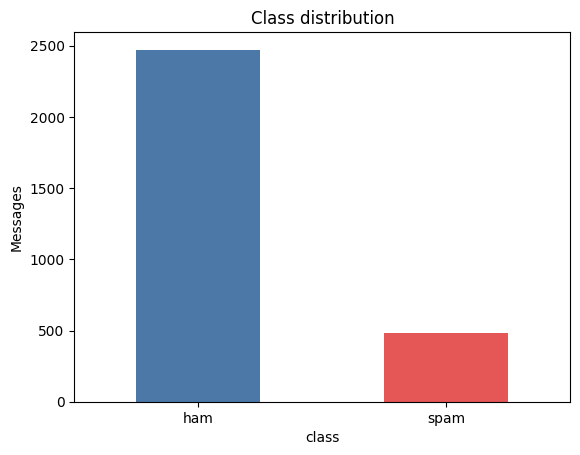

In [7]:
# Read each email with its folder's label: ham is 0 and spam is 1.
records = []
for folder, label in (("easy_ham", 0), ("spam", 1)):
    for path in sorted((data_dir / folder).rglob("*")):
        if path.is_file() and path.name.lower() != "cmds":
            records.append({"path": str(path), "text": read_email(path), "label": label})

# Remove repeated text before splitting, and keep a hash to identify each message.
emails = pd.DataFrame(records).drop_duplicates("text").reset_index(drop=True)
emails["sha256"] = emails["text"].map(lambda text: hashlib.sha256(text.encode()).hexdigest())
emails["class"] = emails["label"].map({0: "ham", 1: "spam"})

class_counts = emails["class"].value_counts().reindex(["ham", "spam"])
display(class_counts.rename("messages").to_frame())
class_counts.plot.bar(color=["#4C78A8", "#E45756"], rot=0, ylabel="Messages", title="Class distribution")
plt.show()

## Split the data

Use the same stratified 70/15/15 split for both models. The second split takes 15/85 of the remaining records for validation. Save the membership and text hashes so the split can be traced later.

Exact extracted-text duplicates have already been removed. This does not rule out similar campaigns or messages that become identical after normalization.

In [8]:
# Set aside the test emails while keeping a similar ham/spam balance.
train_val, test = train_test_split(
    emails, test_size=test_size, stratify=emails["label"], random_state=seed,
)
# Take the validation share from the remaining data, leaving 70% for training.
train, val = train_test_split(
    train_val,
    test_size=val_size / (1 - test_size),
    stratify=train_val["label"],
    random_state=seed,
)
train, val, test = [frame.reset_index(drop=True) for frame in (train, val, test)]

# Save which emails went into each split so the experiment can be traced later.
manifest = pd.concat([
    frame[["path", "label", "sha256"]].assign(split=name)
    for name, frame in (("train", train), ("validation", val), ("test", test))
], ignore_index=True)
manifest[["split", "path", "label", "sha256"]].to_csv(processed_dir / "split_manifest.csv", index=False)
display(pd.crosstab(manifest["split"], manifest["label"]).rename(columns={0: "ham", 1: "spam"}))

label,ham,spam
split,,
test,371,72
train,1730,337
validation,371,72


## Clean the text

Lowercase the text, replace links and email addresses with markers, and remove punctuation. This keeps their presence but loses the original addresses, URL structure and non-ASCII letters.

There is no stemming or lemmatization yet. That remains a gap against the assignment brief.

In [9]:
url_pattern = re.compile(r"(?:https?://|www\.)\S+", re.I)
email_pattern = re.compile(r"\b[\w.+-]+@[\w.-]+\.[A-Za-z]{2,}\b")
non_word = re.compile(r"[^a-z0-9_]+")

def normalize(text):
    # Replace links and addresses with markers, then strip punctuation and extra spaces.
    text = url_pattern.sub(" urltoken ", text.lower())
    text = email_pattern.sub(" emailtoken ", text)
    return whitespace.sub(" ", non_word.sub(" ", text)).strip()

### Evaluation

Use the same 0.5 cutoff for both models. Save precision, recall, F1 and confusion counts, then plot ROC and precision-recall curves using the prediction scores. Any future threshold tuning should use validation data, not the test set.

In [10]:
def show_results(name, labels, probs, filename):
    # Keep the same cutoff for both models.
    preds = (probs >= 0.5).astype(int)
    # Collect the test scores and save them for the report.
    metrics = {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0),
        "roc_auc": roc_auc_score(labels, probs),
        "average_precision": average_precision_score(labels, probs),
        "confusion_matrix": confusion_matrix(labels, preds).tolist(),
        "classification_report": classification_report(
            labels, preds, target_names=["ham", "spam"], output_dict=True, zero_division=0,
        ),
    }
    (results_dir / "metrics" / f"{filename}.json").write_text(json.dumps(metrics, indent=2))

    # Show the prediction errors alongside ROC and precision-recall curves.
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    ConfusionMatrixDisplay.from_predictions(
        labels, preds, display_labels=["ham", "spam"], cmap="Blues", colorbar=False, ax=axes[0],
    )
    axes[0].set_title("Confusion matrix")
    fpr, tpr, _ = roc_curve(labels, probs)
    axes[1].plot(fpr, tpr)
    axes[1].plot([0, 1], [0, 1], "--", color="grey")
    axes[1].set(xlabel="False positive rate", ylabel="True positive rate", title=f"ROC AUC: {metrics['roc_auc']:.3f}")
    precision, recall, _ = precision_recall_curve(labels, probs)
    axes[2].plot(recall, precision)
    axes[2].set(xlabel="Recall", ylabel="Precision", title=f"Average precision: {metrics['average_precision']:.3f}")
    fig.suptitle(name)
    fig.tight_layout()
    fig.savefig(results_dir / "figures" / f"{filename}-evaluation.png", dpi=180)
    plt.show()
    return metrics

## Logistic Regression

Use TF-IDF unigrams and bigrams with English stopwords removed. The vectorizer and classifier are fitted together using only the training emails; balanced class weights account for the smaller spam class.

The function name `normalize` is kept because saved joblib pipelines refer to it. Run that definition before loading a saved pipeline.

In [ ]:
# Use words and two-word phrases as TF-IDF features for Logistic Regression.
lr_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        preprocessor=normalize, stop_words="english", ngram_range=(1, 2),
        max_features=20000, min_df=2, max_df=0.98, sublinear_tf=True,
    )),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=seed)),
])
# Learn the vocabulary and IDF weights from training emails only.
lr_model.fit(train["text"], train["label"])
# Column 1 gives the score for spam.
lr_probs = lr_model.predict_proba(test["text"])[:, 1]
lr_metrics = show_results(
    "TF-IDF Logistic Regression", test["label"].to_numpy(),
    lr_probs, "classic",
)
joblib.dump(lr_model, model_dir / "tfidf-logistic-regression.joblib")
display(pd.Series(lr_metrics).loc[["accuracy", "precision", "recall", "f1", "roc_auc", "average_precision"]].to_frame("score"))

## LSTM

Use a training-only word vocabulary and keep stopwords for this model. Reserve token 0 for padding and token 1 for unknown words. Each email is limited to 300 tokens.

In [ ]:
max_vocab = 20000
max_len = 300
batch_size = 64

def tokenize(text):
    return normalize(text).split()

# Build the vocabulary from training emails only.
word_counts = Counter(token for text in train["text"] for token in tokenize(text))
vocab = {"<PAD>": 0, "<UNK>": 1}
vocab.update({token: index for index, (token, _) in enumerate(word_counts.most_common(max_vocab - 2), 2)})

def encode_text(text):
    # Use UNK for empty text so there is a final token.
    tokens = [vocab.get(token, 1) for token in tokenize(text)[:max_len]] or [1]
    length = len(tokens)
    # Pad shorter emails with zeros so every batch has the same width.
    return tokens + [0] * (max_len - length), length

### Prepare the dataset

Store token IDs, the actual message lengths and labels as tensors for the data loaders.

In [ ]:
class EmailDataset(Dataset):
    def __init__(self, frame):
        # Convert each email to tensors once, ready for the data loader.
        encoded = [encode_text(text) for text in frame["text"]]
        self.tokens = torch.tensor([item[0] for item in encoded], dtype=torch.long)
        self.lengths = torch.tensor([item[1] for item in encoded], dtype=torch.long)
        self.labels = torch.tensor(frame["label"].to_numpy(), dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        return self.tokens[index], self.lengths[index], self.labels[index]

### Define the model

A 128-dimensional embedding feeds a 128-unit LSTM, followed by dropout and one output logit. Prediction uses evaluation mode so dropout is disabled.

In [ ]:
class EmailLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(len(vocab), 128, padding_idx=0)
        self.lstm = nn.LSTM(128, 128, batch_first=True)
        self.dropout = nn.Dropout(0.3)
        self.output = nn.Linear(128, 1)

    def forward(self, tokens, lengths):
        # Turn word IDs into learned vectors, then read them in order with the LSTM.
        sequence, _ = self.lstm(self.embedding(tokens))
        rows = torch.arange(len(lengths), device=tokens.device)
        # Use the last real word, not a padding token.
        return self.output(self.dropout(sequence[rows, lengths - 1])).squeeze(1)

def predict_lstm(model, loader, device):
    # Turn off dropout and gradient tracking while making predictions.
    model.eval()
    probs, labels = [], []
    with torch.no_grad():
        for tokens, lengths, batch_labels in loader:
            logits = model(tokens.to(device), lengths.to(device))
            # Sigmoid turns each logit into a spam score between 0 and 1.
            probs.extend(torch.sigmoid(logits).cpu().numpy())
            labels.extend(batch_labels.numpy())
    return np.asarray(labels, dtype=int), np.asarray(probs)

### Set up training

Use CUDA for the LSTM if available; Logistic Regression stays on the CPU. Weight spam examples by the training ham/spam ratio and optimize the binary loss with AdamW.

In [ ]:
# Shuffle training batches, but keep validation and test order fixed.
generator = torch.Generator().manual_seed(seed)
train_loader = DataLoader(EmailDataset(train), batch_size=batch_size, shuffle=True, generator=generator)
val_loader = DataLoader(EmailDataset(val), batch_size=batch_size)
test_loader = DataLoader(EmailDataset(test), batch_size=batch_size)

# Use a GPU if the runtime provides one.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
lstm_model = EmailLSTM().to(device)
# Give spam examples more weight in the loss.
spam_weight = torch.tensor([(len(train) - train["label"].sum()) / train["label"].sum()], device=device)
loss_fn = nn.BCEWithLogitsLoss(pos_weight=spam_weight)
optimizer = torch.optim.AdamW(lstm_model.parameters(), lr=0.001)

### Train and evaluate

Run the fixed epoch budget and restore the weights with the best validation F1. This is checkpoint selection, not early stopping. The history plots training loss and validation F1; validation loss is not computed.

The saved LSTM file contains weights and vocabulary. Its architecture and preprocessing still come from this notebook.

In [ ]:
history = []
best_val_f1 = -1
for epoch in range(1, epochs + 1):
    lstm_model.train()
    total_loss = 0
    for tokens, lengths, labels in train_loader:
        tokens, lengths, labels = tokens.to(device), lengths.to(device), labels.to(device)
        # Clear the old gradients, calculate the loss, then update the weights.
        optimizer.zero_grad()
        loss = loss_fn(lstm_model(tokens, lengths), labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(labels)

    # Check validation F1 after each epoch without updating the model.
    y_val, val_probs = predict_lstm(lstm_model, val_loader, device)
    val_f1 = f1_score(y_val, val_probs >= 0.5)
    history.append({"epoch": epoch, "training_loss": total_loss / len(train), "validation_f1": val_f1})
    # Keep the weights with the best validation F1.
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state = {name: value.detach().cpu().clone() for name, value in lstm_model.state_dict().items()}

lstm_model.load_state_dict(best_state)
history_df = pd.DataFrame(history)
display(history_df)
history_df.set_index("epoch").plot(subplots=True, figsize=(7, 5), title=["Training loss", "Validation F1"])
plt.tight_layout()
plt.savefig(results_dir / "figures/lstm-training-history.png", dpi=180)
plt.show()

# Test the best checkpoint, then save its scores, weights and vocabulary.
y_test, lstm_probs = predict_lstm(lstm_model, test_loader, device)
lstm_metrics = show_results("LSTM", y_test, lstm_probs, "lstm")
lstm_metrics.update({"best_validation_f1": best_val_f1, "epochs": epochs, "device": str(device)})
(results_dir / "metrics/lstm.json").write_text(json.dumps(lstm_metrics, indent=2))
torch.save({"model_state": best_state, "vocabulary": vocab}, model_dir / "lstm.pt")
display(pd.Series(lstm_metrics).loc[["accuracy", "precision", "recall", "f1", "roc_auc", "average_precision"]].to_frame("score"))

## Compare the models

Compare both models on the same test emails, then save the metrics, figures and model files. In Colab, these files are on the remote runtime: the ZIP must be copied back to the local repository. It contains reports and models, but not the processed split manifest.

In [ ]:
metric_names = ["accuracy", "precision", "recall", "f1", "roc_auc", "average_precision"]
# Put both models' test scores in one table.
comparison = pd.DataFrame([
    {"model": "TF-IDF Logistic Regression", **{metric: lr_metrics[metric] for metric in metric_names}},
    {"model": "LSTM", **{metric: lstm_metrics[metric] for metric in metric_names}},
])
comparison.to_csv(results_dir / "model-comparison.csv", index=False)

# Record the data counts and training length alongside the scores.
summary = {
    "records_after_deduplication": len(emails),
    "train_records": len(train),
    "validation_records": len(val),
    "test_records": len(test),
    "ham": int((emails["label"] == 0).sum()),
    "spam": int((emails["label"] == 1).sum()),
    "lstm_epochs": epochs,
}
(results_dir / "run-summary.json").write_text(json.dumps(summary, indent=2))
display(comparison.style.format({metric: "{:.4f}" for metric in metric_names}).highlight_max(subset=metric_names, color="#d9ead3"))

# Bundle the remote results and models so they can be downloaded from Colab.
if in_colab:
    export_dir = root / "section_01_export"
    shutil.copytree(results_dir, export_dir / "reports", dirs_exist_ok=True)
    shutil.copytree(model_dir, export_dir / "models", dirs_exist_ok=True)
    shutil.make_archive("/content/section_01_results", "zip", root_dir=export_dir)

## What to take from the results

- Compare precision, recall, F1 and the ROC/PR curves, not just accuracy. A false positive is a legitimate email flagged as spam; a false negative is missed spam.
- These old spam/ham labels do not establish performance on modern phishing emails. Exact deduplication also leaves possible campaign overlap.
- The saved notebook outputs and files in `reports/section_01` can describe different runs. Do not mix them when writing up results.

The [alignment review](../../docs/assignment/LECTURE_NOTEBOOK_ALIGNMENT.md) records the remaining methodological issues. This style revision does not change the models, preprocessing or evaluation.